# Introduction

This notebook analyzes the Sample Superstore dataset (9994 orders, 21 columns) to uncover key business insights around sales, profit, customer segments, and discount impact across US regions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("Sample - Superstore.csv",encoding='latin-1')

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [33]:
df.describe()

,Row ID,Order Date,Postal Code,Sales,Quantity,Discount,Profit,Month,Year
count,9994.000000,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355,55190.379428,229.858001,3.789574,0.156203,28.656896,7.809686,2015.722233
min,1.000000,2014-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,1.000000,2014.000000
25%,2499.250000,2015-05-23 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,5.000000,2015.000000
50%,4997.500000,2016-06-26 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,9.000000,2016.000000
75%,7495.750000,2017-05-14 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,11.000000,2017.000000
max,9994.000000,2017-12-30 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,12.000000,2017.000000
std,2885.163629,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,3.284654,1.123555


# Q1. Which region generates the most profit?

In [11]:
df.groupby('Region')[['Sales','Quantity','Profit']].sum().reset_index().sort_values('Profit',ascending=False)

,Region,Sales,Quantity,Profit
3,West,725457.8245,12266,108418.4489
1,East,678781.2400,10618,91522.7800
2,South,391721.9050,6209,46749.4303
0,Central,501239.8908,8780,39706.3625


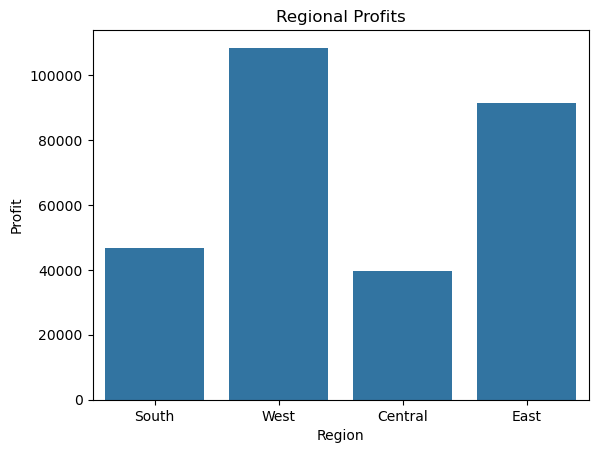

In [20]:
sns.barplot(data=df,x='Region',y='Profit',estimator=sum,errorbar=None)
plt.title("Regional Profits")
plt.show()

## Insight: West region generates the highest profit (~108K), while Central underperforms significantly (~40K) and may need pricing or discount strategy review.

# Q2. Which category/sub-category makes the most revenue

In [16]:
category_sales=df.groupby(['Category','Sub-Category'])[['Sales','Profit']].sum().reset_index().sort_values('Sales',ascending=False)
category_sales

,Category,Sub-Category,Sales,Profit
16,Technology,Phones,330007.0540,44515.7306
1,Furniture,Chairs,328449.1030,26590.1663
11,Office Supplies,Storage,223843.6080,21278.8264
3,Furniture,Tables,206965.5320,-17725.4811
6,Office Supplies,Binders,203412.7330,30221.7633
15,Technology,Machines,189238.6310,3384.7569
13,Technology,Accessories,167380.3180,41936.6357
14,Technology,Copiers,149528.0300,55617.8249
0,Furniture,Bookcases,114879.9963,-3472.5560
4,Office Supplies,Appliances,107532.1610,18138.0054


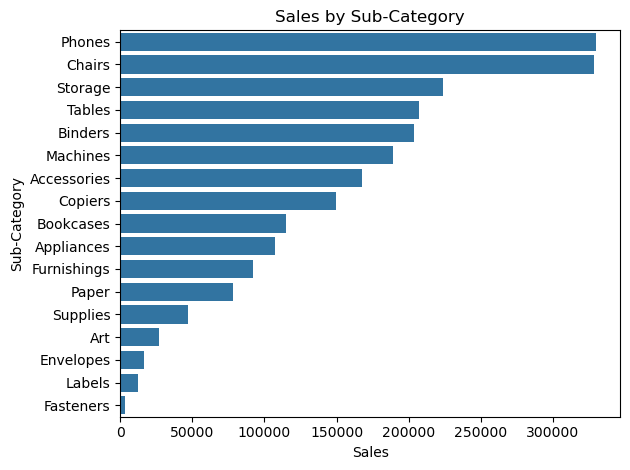

In [17]:
sns.barplot(data=category_sales,x='Sales',y='Sub-Category',estimator=sum,errorbar=None,orient='h')
plt.title('Sales by Sub-Category')
plt.tight_layout()
plt.show()

## Insight: Phones are the highest revenue generating sub-category (~330K), followed by Chairs (~328K) but Copiers generate the most profit (~56K). Tables and Bookcases are losing money despite decent sales - discount or pricing issue.

# Q3. Which customer segment is most profitable?

In [18]:
df.groupby('Segment')[['Sales','Profit']].sum().reset_index().sort_values('Profit',ascending=False)

,Segment,Sales,Profit
0,Consumer,1.161401e+06,134119.2092
1,Corporate,7.061464e+05,91979.1340
2,Home Office,4.296531e+05,60298.6785


Text(0.5, 1.0, 'Profit by Segment')

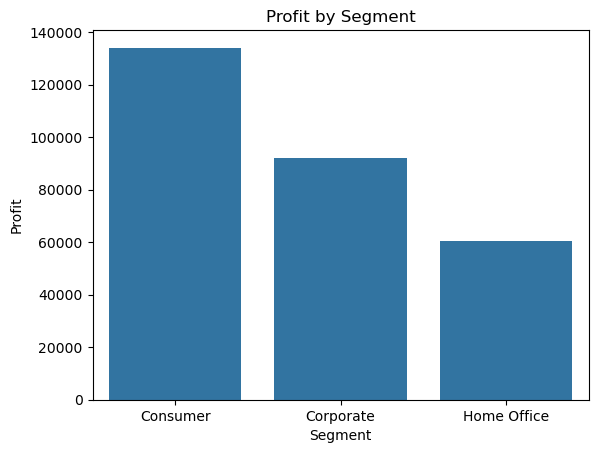

In [21]:
sns.barplot(data=df,x='Segment',y='Profit',estimator=sum,errorbar=None)
plt.title('Profit by Segment')

## Insight: Consumer segment is the most profitable (~134K), contributing nearly half of total profits compared to Home Office (~60K).

# Q4. How do sales trend over time?

In [25]:
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Month']=df['Order Date'].dt.month
df['Year']=df['Order Date'].dt.year
yearly_data=df.groupby(['Year'])[['Sales','Profit']].sum().reset_index().sort_values('Sales',ascending=False)
yearly_data

,Year,Sales,Profit
3,2017,733215.2552,93439.2696
2,2016,609205.5980,81795.1743
0,2014,484247.4981,49543.9741
1,2015,470532.5090,61618.6037


Text(0.5, 1.0, 'Sales trend over years')

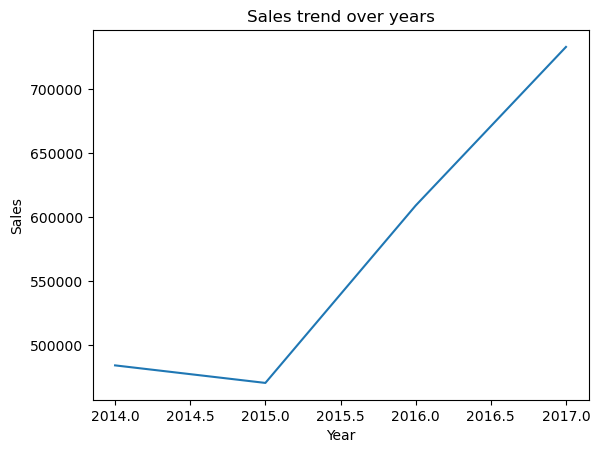

In [27]:
sns.lineplot(data=yearly_data,x='Year',y='Sales')
plt.title('Sales trend over years')

## Insight: Sales dipped in 2015 but recovered strongly, reaching peak in 2017 showing consistent growth.

# Q.5 Does discount lead to profit?

Text(0.5, 1.0, 'Discount v/s Profit')

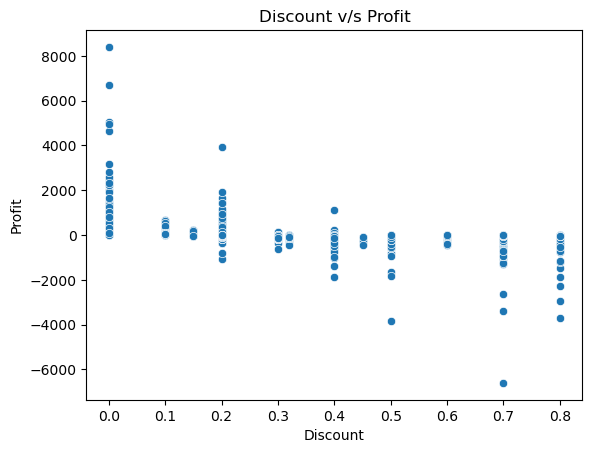

In [32]:
sns.scatterplot(data=df,x='Discount',y='Profit')
plt.title('Discount v/s Profit')

## Insight: as discount increases profit decreases

# Conclusion

- West region is the most profitable (~108K), Central region underperforms and needs strategy review
- Phones have highest sales (~330K) but Copiers are most profitable (~56K). Tables and Bookcases are losing money
- Consumer segment dominates profit (~134K), contributing nearly half of total profits
- Sales dipped in 2015 but recovered strongly, reaching peak in 2017
- Higher discounts consistently lead to lower or negative profits — discount strategy needs review